<a href="https://colab.research.google.com/github/RBOM12/tpValorisationdeladonn-es/blob/main/TP2_BROCHET_Valorisation_de_la_donn%C3%A9es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, make_blobs
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score

In [ ]:

X_normal, y_normal = make_blobs(n_samples=300, centers=[[0, 0]], n_features=2,
                  random_state=42, cluster_std = 0.5)
anomalies = np.random.uniform(low=-5.0, high=5.0, size=(30, 2))
X = np.vstack((X_normal, anomalies))
print(X.shape)

In [ ]:
# Création d'un vecteur de 30 "-1" pour les anomalies
y_anomalies = np.full(30, -1)
y = np.ones(300)
# On assemble le tout dans le même ordre que pour la matrice X
y = np.concatenate((y, y_anomalies))

for i in range(len(X)):
    if y[i] == -1:
        distance_au_centre = np.linalg.norm(X[i] - [0, 0])
        if distance_au_centre < 1.5:
            y[i] = 1


In [ ]:

plt.figure(figsize=(10, 7))

# Affichage des données régulières (y=1)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='royalblue', label='Données régulières (1)', alpha=0.6)

# Affichage des anomalies restantes (y=-1)
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], c='crimson', label='Anomalies (-1)', marker='x')

plt.title("Visualisation du jeu de données (Cluster + Anomalies)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



*   Élément de liste
*   Élément de liste



In [ ]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest()
y_pred = clf.fit_predict(X)

def show(y) :
  plt.figure(figsize=(10, 7))
  plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
              c='mediumseagreen', label='Prédit : Régulier (1)', alpha=0.6)

  # Affichage des points prédits comme anomalies (-1) en orange
  plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1],
              c='darkorange', label='Prédit : Anomalie (-1)', marker='x', s=60)

  plt.title("Détection d'anomalies par Isolation Forest")
  plt.xlabel("Dimension 1")
  plt.ylabel("Dimension 2")
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.show()

  # Affichage du nombre d'anomalies détectées
  nb_anomalies = (y_pred == -1).sum()
  print(f"Nombre d'anomalies détectées : {nb_anomalies}")

show(y_pred)

Avec plusieurs exécutions je trouve des différences minimes où le modèles peut me sortir

In [ ]:


for i in range(0,100,10):
  clf = IsolationForest(random_state=i)
  y_pred = clf.fit_predict(X)
  show(y_pred)
  print(i)


Ils sont tous différents mais on ne retrouve pas de véritable patern qui se dessine

In [ ]:
i = 0.0
while i <0.5 :
  i+=0.1
  clf = IsolationForest(random_state=42 , contamination=i)
  y_pred = clf.fit_predict(X)
  show(y_pred)

  print(i)

Plus la contamination est élevé plus le modèle resort un grand nombre d'anomalies. Alors quelles ne le sont pas

In [ ]:
scores = clf.decision_function(X)
plt.figure(figsize=(10, 6))
plt.hist(scores, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Ajout d'une ligne verticale pour le seuil par défaut de sklearn (0.0)
plt.axvline(x=0, color='red', linestyle='--', label='Seuil par défaut (0.0)')

plt.title("Distribution des scores d'anomalies (Isolation Forest)")
plt.xlabel("Score d'anomalie (plus bas = plus anormal)")
plt.ylabel("Nombre de points")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Affichage de quelques statistiques sur les scores
print(f"Score minimum : {scores.min():.4f}")
plt.show()
print(f"Score maximum : {scores.max():.4f}")

Il est difficile de choisir un seuil d'anomalie mais on pourrait estimer que -0.05 serait un bon seuil à vu d'oeil.

In [ ]:
plt.figure(figsize=(12, 8))
# 2. Affichage des points avec une échelle de couleur (colormap)
scatter = plt.scatter(X[:, 0], X[:, 1], c=scores, cmap='viridis', s=50, alpha=0.8)

# 3. Ajout d'une barre de couleur pour expliquer les scores
cbar = plt.colorbar(scatter)
cbar.set_label("Score d'anomalie (Décroissant = Plus anormal)")

plt.title("Visualisation continue des scores d'Isolation Forest")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Les anomalies sont bien représenté loindu centre masi certaines proche du centre en fonction du seuil pourrait être défini comme une anomalie

In [ ]:
def showanomalie (seuil):
  plt.figure(figsize=(12, 8))
  # 2. Affichage des points avec une échelle de couleur (colormap)
  scatter = plt.scatter(X[:, 0], X[:, 1], c=(scores<seuil), cmap='coolwarm', s=50, alpha=0.8)

  # 3. Ajout d'une barre de couleur pour expliquer les scores
  cbar = plt.colorbar(scatter)
  cbar.set_label("Score d'anomalie (Décroissant = Plus anormal)")

  plt.title("Visualisation continue des scores d'Isolation Forest")
  plt.xlabel("Dimension 1")
  plt.ylabel("Dimension 2")
  plt.grid(True, linestyle='--', alpha=0.3)
  plt.show()

i = 0.0
while i >-0.25 :
  i-=0.05
  showanomalie(i)
  print(i)

In [ ]:
from sklearn.metrics import roc_auc_score
clf = IsolationForest(random_state=42 , contamination=0.09)
y_pred = clf.fit_predict(X)
show(y_pred)

scores_final = clf.decision_function(X)

auc = roc_auc_score(y_pred, scores_final)

print(f"L'AUC du modèle est de : {auc:.4f}")


La forêt d'isolation à bien fait la détection des anomalie vu que l'on se retrouve avec un score d'AUC de 1

## One-class SVMs

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

In [ ]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Moyenne après normalisation :", np.mean(X_scaled, axis=0))
print("Écart-type après normalisation :", np.std(X_scaled, axis=0))

Moyenne après normalisation : [1.21115239e-17 9.42007415e-18]
Écart-type après normalisation : [1. 1.]


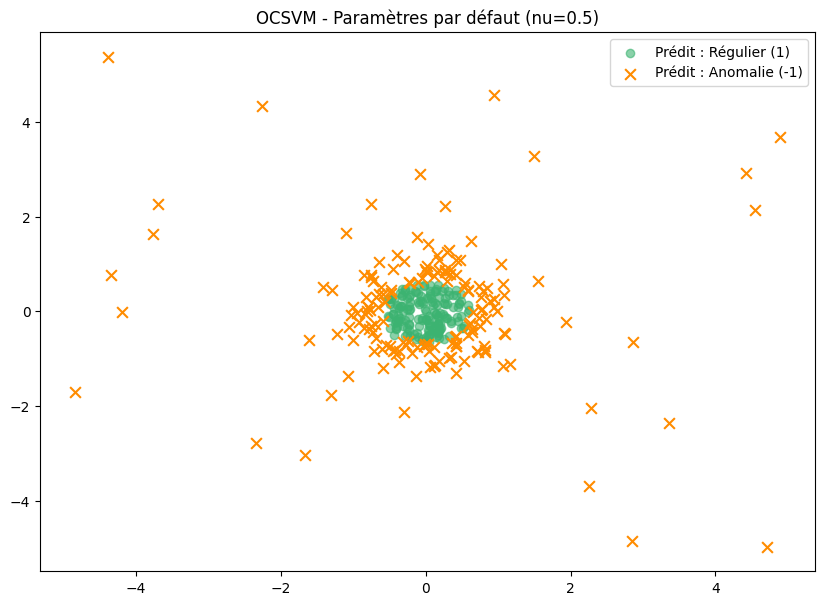

In [ ]:
# 1. Construction du modèle par défaut
ocsvm_default = OneClassSVM()
y_pred_default = ocsvm_default.fit_predict(X_scaled)

# 2. Affichage
plt.figure(figsize=(10, 7))
plt.scatter(X_scaled[y_pred_default == 1][:, 0], X_scaled[y_pred_default == 1][:, 1],
            c='mediumseagreen', label='Prédit : Régulier (1)', alpha=0.6)
plt.scatter(X_scaled[y_pred_default == -1][:, 0], X_scaled[y_pred_default == -1][:, 1],
            c='darkorange', label='Prédit : Anomalie (-1)', marker='x', s=60)

plt.title("OCSVM - Paramètres par défaut (nu=0.5)")
plt.legend()
plt.show()

Beaucoup trop de valeurs sont définies comme des anomalies. On va donc faire varier les paramètres.

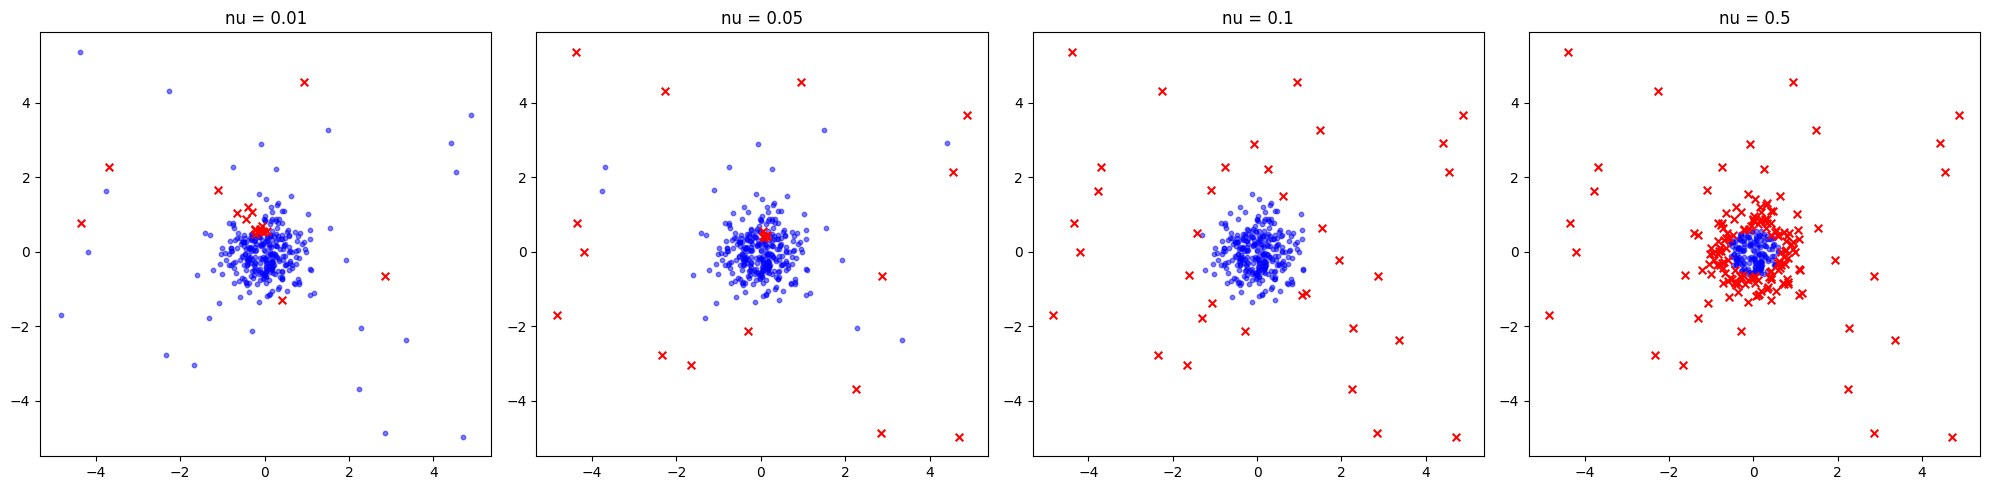

In [ ]:
nus = [0.01, 0.05, 0.1, 0.5]
plt.figure(figsize=(20, 5))

for i, nu in enumerate(nus):
    model = OneClassSVM(nu=nu, kernel="rbf", gamma=0.1)
    preds = model.fit_predict(X_scaled)

    plt.subplot(1, 4, i+1)
    plt.scatter(X_scaled[preds == 1][:, 0], X_scaled[preds == 1][:, 1], c='blue', s=10, alpha=0.5)
    plt.scatter(X_scaled[preds == -1][:, 0], X_scaled[preds == -1][:, 1], c='red', marker='x', s=30)
    plt.title(f"nu = {nu}")

plt.tight_layout()
plt.show()

Nu 0.1 est le plus proche de la réalité et le plus cohérent il faut donc trouver un juste milieux entre une valeur trop élevée comme 0.5 ou trop faible commme 0.05 ou 0.01

In [ ]:
# Meilleur modèle (nu =0.1)
best_ocsvm = OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)
best_ocsvm.fit(X_scaled)

# On utilise decision_function pour avoir des valeurs continues pour l'AUC
scores_ocsvm = best_ocsvm.decision_function(X_scaled)

# Calcul de l'AUC
auc_ocsvm = roc_auc_score(y, scores_ocsvm)

print(f"L'AUC du meilleur OCSVM (nu=0.1) est de : {auc_ocsvm:.4f}")

L'AUC du meilleur OCSVM (nu=0.1) est de : 0.9996


L'AUC pour le meilleur résultat est de 0.9996 très proche de 1 avec une valeur de nu de 0.1.

## LOF

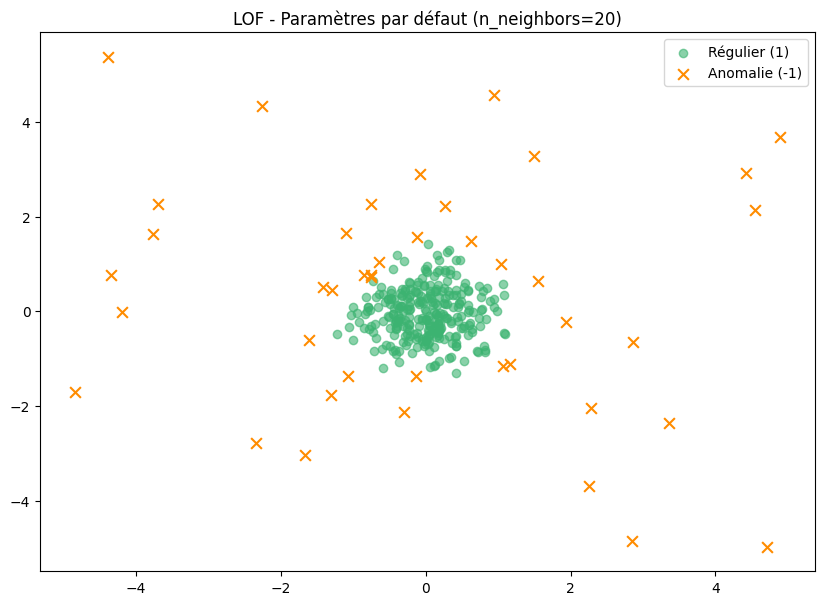

nombre d'anomalie 42


In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# 1. Application de LOF
# Note : Pour LOF, on utilise fit_predict
lof_default = LocalOutlierFactor(n_neighbors=20)
y_pred_lof = lof_default.fit_predict(X_scaled)

# 2. Affichage
plt.figure(figsize=(10, 7))
plt.scatter(X_scaled[y_pred_lof == 1][:, 0], X_scaled[y_pred_lof == 1][:, 1],
            c='mediumseagreen', label='Régulier (1)', alpha=0.6)
plt.scatter(X_scaled[y_pred_lof == -1][:, 0], X_scaled[y_pred_lof == -1][:, 1],
            c='darkorange', label='Anomalie (-1)', marker='x', s=60)

plt.title("LOF - Paramètres par défaut (n_neighbors=20)")
plt.legend()
plt.show()
print("nombre d'anomalie", (y_pred_lof==-1).sum()  )

1. Le résultat est un peu plus élevé que la réalité avec 42 anomalies détecté. Il a tendance à sélectionné plus de valeur

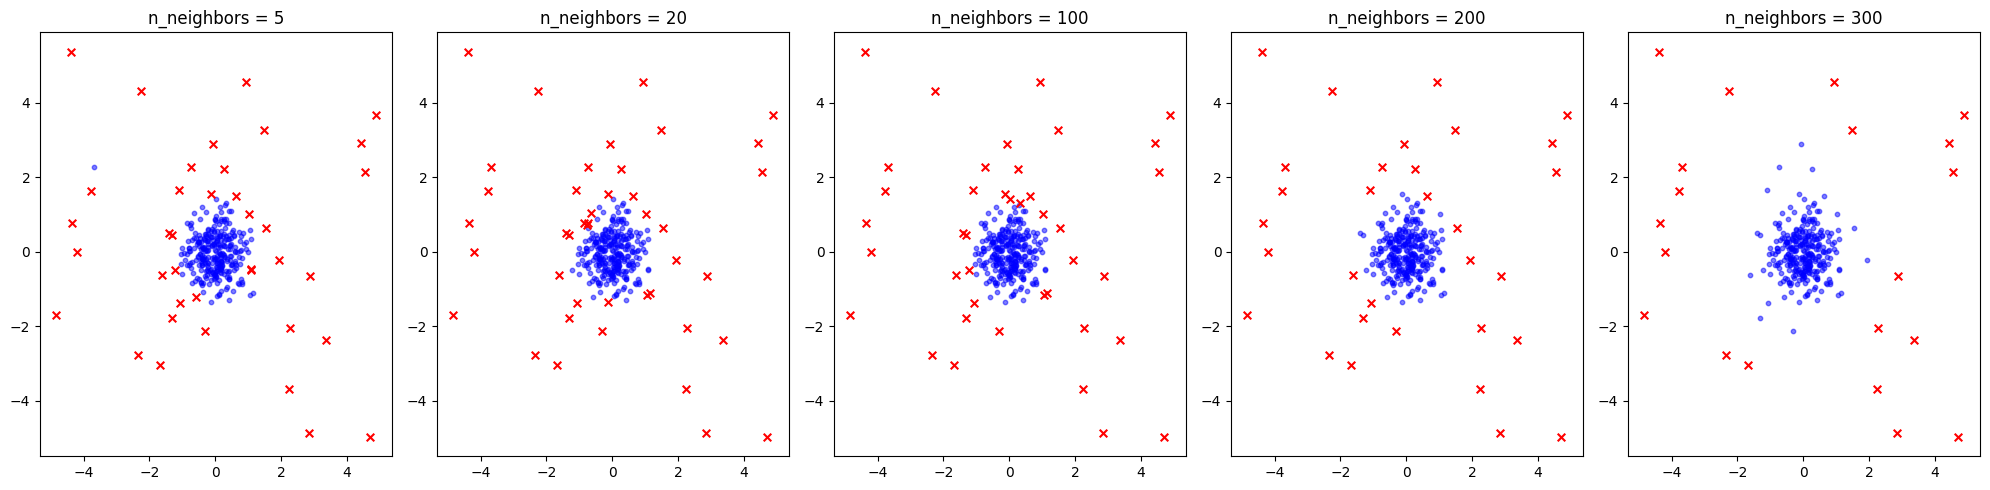

In [ ]:
neighbors_list = [5, 20, 100,200, 300]
plt.figure(figsize=(20, 5))

for i, k in enumerate(neighbors_list):
    lof_model = LocalOutlierFactor(n_neighbors=k)
    preds = lof_model.fit_predict(X_scaled)

    plt.subplot(1, 5, i+1)
    plt.scatter(X_scaled[preds == 1][:, 0], X_scaled[preds == 1][:, 1], c='blue', s=10, alpha=0.5)
    plt.scatter(X_scaled[preds == -1][:, 0], X_scaled[preds == -1][:, 1], c='red', marker='x', s=30)
    plt.title(f"n_neighbors = {k}")

plt.tight_layout()
plt.show()

2. Plus je prends en comptes les proches voisins moins je détecte d'anomalies

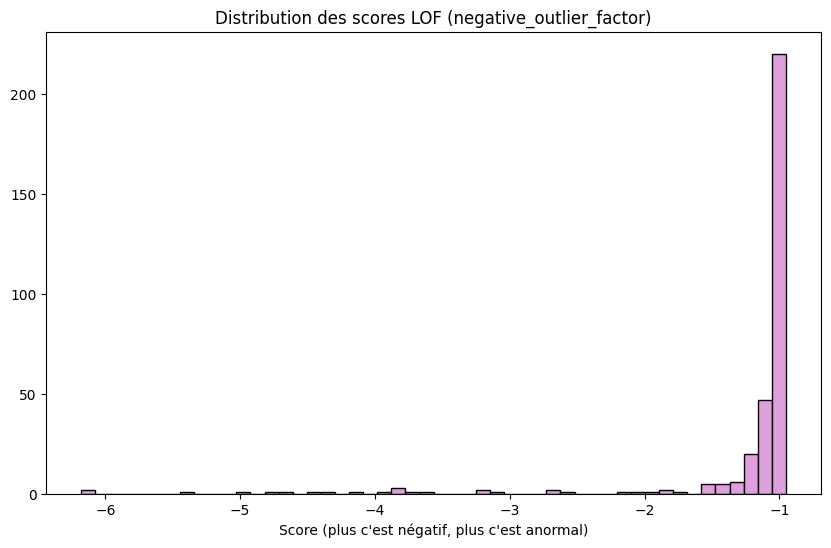

In [ ]:
lof_score_model = LocalOutlierFactor(n_neighbors=200)
lof_score_model.fit_predict(X_scaled)

# Récupération des scores (négatifs)
lof_scores = lof_score_model.negative_outlier_factor_

plt.figure(figsize=(10, 6))
plt.hist(lof_scores, bins=50, color='plum', edgecolor='black')
plt.title("Distribution des scores LOF (negative_outlier_factor)")
plt.xlabel("Score (plus c'est négatif, plus c'est anormal)")
plt.show()

Il est difficile de définir un seuil mais il se trouverais entre -1,5 et -2 c'est la ou le nombre de valeur devient vraiment minime

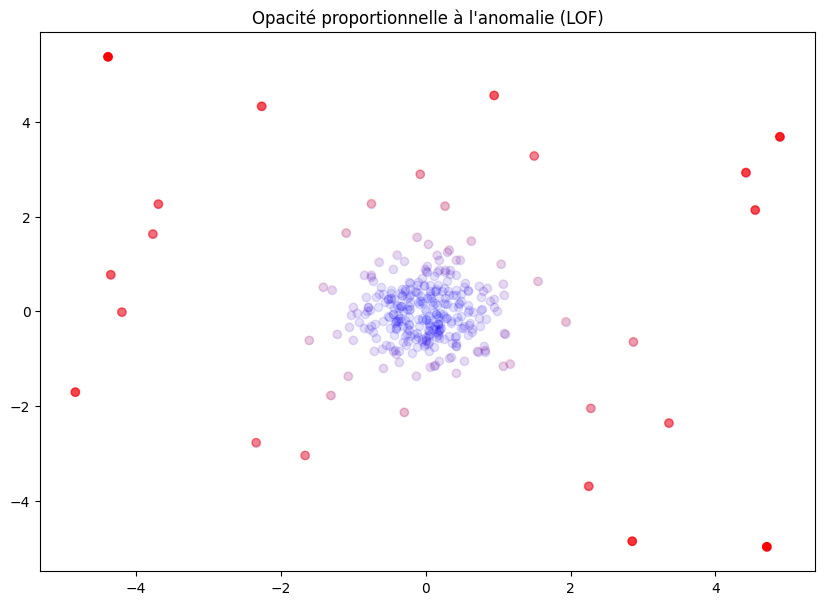

In [ ]:
# On normalise les scores pour l'opacité (0 = transparent, 1 = opaque)
norm_scores = (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min())

plt.figure(figsize=(10, 7))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='blue', alpha=0.1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='red', alpha=1 - norm_scores)

plt.title("Opacité proportionnelle à l'anomalie (LOF)")
plt.show()

4. On remarque que certaine anomalie se confonde fortement avec des scores normaux

In [ ]:
lof_final = LocalOutlierFactor(n_neighbors=200, contamination=0.09)
y_pred_final_lof = lof_final.fit_predict(X_scaled)
auc_lof = roc_auc_score(y, lof_scores)

print(f"L'AUC pour l'algorithme LOF est de : {auc_lof:.4f}")

L'AUC pour l'algorithme LOF est de : 0.9995


## données réelle

In [ ]:

# 1. Chargement du fichier avec loadtxt
# Le fichier est présent dans mon Colab
data = np.loadtxt('annthyroid.csv', delimiter=',')

X_raw = data[:, :-1]
y_raw = data[:, -1]

# Transformation des étiquettes :
# Dans le fichier : 0 (régulier), 1 (anomalie)
# Pour sklearn : 1 (régulier), -1 (anomalie)
y_true = np.where(y_raw == 0, 1, -1)

# Calcul de la proportion réelle d'anomalies (utile pour les hyperparamètres)
contamination_reelle = np.sum(y_true == -1) / len(y_true)
print(f"Nombre d'observations : {X_raw.shape[0]}")
print(f"Taux de contamination réel : {contamination_reelle:.2%}")

# 2. Normalisation (StandardScaler)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

Nombre d'observations : 7200
Taux de contamination réel : 7.42%


In [ ]:


# Initialisation des modèles
models = {
    "Isolation Forest": IsolationForest(contamination=contamination_reelle, random_state=42),
    "One-Class SVM": OneClassSVM(nu=contamination_reelle, kernel="rbf"),
    "LOF": LocalOutlierFactor(n_neighbors=200, contamination=contamination_reelle)
}

auc_results = {}

for name, model in models.items():
    if name == "LOF":
        model.fit_predict(X)
        scores = model.negative_outlier_factor_
    else:
        model.fit(X)
        scores = model.decision_function(X)

    # Calcul de l'AUC
    auc = roc_auc_score(y_true, scores)
    auc_results[name] = auc
    print(f"AUC {name} : {auc:.4f}")

AUC Isolation Forest : 0.8014
AUC One-Class SVM : 0.5646
AUC LOF : 0.7306


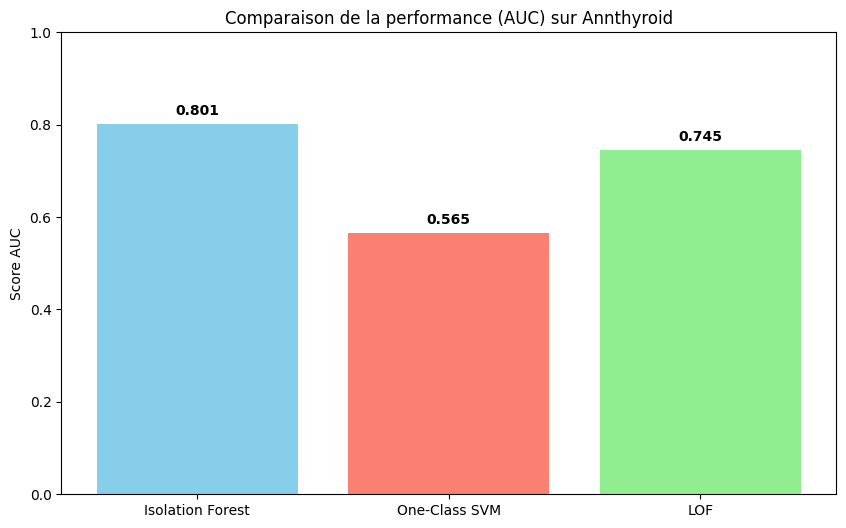

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(auc_results.keys(), auc_results.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.ylim(0, 1)
plt.ylabel("Score AUC")
plt.title("Comparaison de la performance (AUC) sur Annthyroid")

for i, v in enumerate(auc_results.values()):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

plt.show()

L'isolation Forest est bien supérieur que les deux autres modèles avec 0.8 contre 0.745 pour le LOF et 0.565 pour le Onec Class SVM, sur ce genre d'exercice. Il est adapté aux données multidimentionnel et isole bien les anomalies.